# Parte 2.

Ecuaciones diferenciales ordinarias y parciales.

Tambien se establecen condiciones  de frontera de **Dirichlet** y **Neumann** 

Y tambien, jacobianos y hessianos

## Planteamiento del problema
La ecuacion de Poisson es:
    $$f(x)=(x+1)^2$$
    
- El **jacobiano** corresponde a la primera derivada:
$$\frac{df}{dx}=2(x+1)$$

- El **Hessiano** a la segunda:
$$\frac{d^2f}{dx^2}=2$$




Entonces la ecuación de poisson que se va a solucionar es:
$$\frac{d^2u}{dx^2}=2,\qquad x\in[-1,1]$$

La condición de **Dirichlet** en una frontera es:
$$u(-1)=0$$

Y la condición de **Neumann** en la frontera derecha:

$$\left.\frac{du}{dx}\right|_{u=1}=4$$

In [91]:
import deepxde as dde

In [92]:
import tensorflow_probability

In [93]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

dde.backend.backend_name = "pytorch"

In [94]:
def pde(x, y):
    dy_xx = dde.grad.hessian(y,x)
    return dy_xx -2

# Definiendo Condiciones de Frontera:



### Dirichlet

In [95]:
def boundary_value1(x):
    return 0 #Sets u=0

def boundary_1(x,on_boundary):
    return on_boundary and dde.utils.isclose(x[0],-1)

### Neumann

In [96]:
def boundary_flux_r(x):
    return 4 #Set (du/dx) = 4 at all x=1

def boundary_r(x,on_boundary):
    return on_boundary and dde.utils.isclose(x[0],1)

In [97]:
## Exact solution
def func(x):
    return (x+1)**2

### Main PINN Model

In [98]:
geom = dde.geometry.Interval(-1,1)

In [99]:
bc_1=dde.icbc.DirichletBC(geom, boundary_value1,boundary_1)
bc_2=dde.icbc.NeumannBC(geom, boundary_flux_r,boundary_r)


In [100]:
## Data model:
data = dde.data.PDE(geom,
                    pde,
                    [bc_1,bc_2],
                    16,
                    2,
                    solution=func,
                    num_test=100
                   )

In [101]:
layer_size = [1] + [50]*3 + [1]
# [1]: x input layer
# [50]*3: 3 capas ocultas con 50 neuronas
# [1]: y output layer
activation = "tanh"
initializer = "Glorot uniform"

## FNN Fully conected neural network
net = dde.nn.FNN(layer_size,
                activation,
                initializer
                )

In [106]:
model = dde.Model(data,net)
# model is our main neural network object 

model.compile("adam",lr=1e-3,metrics=["l2 relative error"])

losshistory, train_state = model.train(iterations = 500)
                  
    

Compiling model...
'compile' took 0.006833 s

Training model...

Step      Train loss                        Test loss                         Test metric   
0         [5.06e-01, 1.91e-03, 1.77e-03]    [3.84e-01, 1.91e-03, 1.77e-03]    [1.06e-01]    
500       [2.75e-04, 2.63e-09, 5.60e-09]    [2.18e-04, 2.63e-09, 5.60e-09]    [1.15e-03]    

Best model at step 500:
  train loss: 2.75e-04
  test loss: 2.18e-04
  test metric: [1.15e-03]

'train' took 1.631532 s



### Resultados:

Vemos un output de la forma: <br>

    - loss = [4.20e-04, 7.12e-04, 2.63e-04]
    - loss = [pd_loss, dirichlet_loss, neumann_loss]
    

In [107]:
### Solución:

In [108]:
np.linspace(-1,1,10).reshape(-1,1)

array([[-1.        ],
       [-0.77777778],
       [-0.55555556],
       [-0.33333333],
       [-0.11111111],
       [ 0.11111111],
       [ 0.33333333],
       [ 0.55555556],
       [ 0.77777778],
       [ 1.        ]])

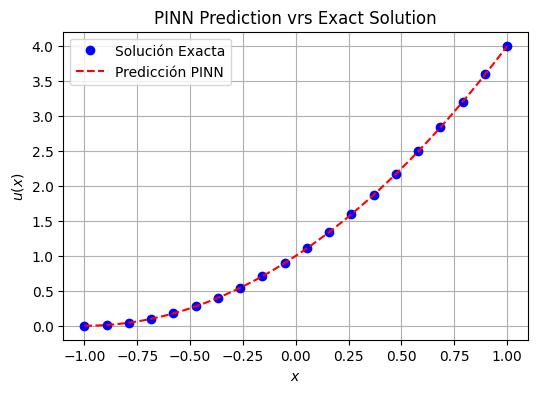

In [109]:
x_values_pinn = np.linspace(-1,1,100).reshape(-1,1)
y_pred        = model.predict(x_values_pinn)

x_values_exact = np.linspace(-1,1,20).reshape(-1,1)
y_exact        = func(x_values_exact)


plt.figure(figsize=(6,4))
plt.plot(x_values_exact,y_exact,'ob',label="Solución Exacta")

plt.plot(x_values_pinn,y_pred,'--r',label="Predicción PINN")

plt.xlabel("$x$")
plt.ylabel("$u(x)$")
plt.title("PINN Prediction vrs Exact Solution")
plt.legend()
plt.grid()
plt.show()